# 🧬🔬 AI for Gut & Microbiome — Exploratory Data Analysis & Visualization

## Project Overview

**Research Question:** *Can taxonomic gut microbiome profiles and ecological diversity metrics reveal distinct signatures across the adenoma-carcinoma colorectal cancer progression sequence?*

### Why This Matters
- The **gut microbiome** plays a pivotal etiologic and regulatory role in colorectal carcinogenesis. Landmark studies published in *Nature Medicine* (2019) and *Cell* (2019) have demonstrated that mucosal barrier breakdown, inflammation, and opportunistic pathobionts drive tumor evolution.
- Early detection is the single most critical factor for colorectal cancer survival (90% 5-year survival at Stage I vs <15% at Stage IV).
- Non-invasive stool metagenomic sequencing offers a transformative alternative to colonoscopy for population-scale screening.

### Dataset: curatedMetagenomicData (Yachida et al., Nature Medicine 2019)
- **347 human participants** across 6 clinically defined cohorts:
  - Healthy Controls ($N = 127$)
  - Stage 0 ($N = 27$)
  - Stage I/II Carcinoma ($N = 69$)
  - Stage III/IV Carcinoma ($N = 54$)
  - Multiple Polypoid Adenomas (MP) ($N = 40$)
  - High-grade Dysplasia (HS) ($N = 30$)
- Matched clinical metadata paired with high-resolution genus and species-level relative abundance matrices.

### What This Notebook Does
1. **Data Loading & Initial Inspection** — Verify schema integrity, data types, and sample dimensions
2. **Missing Value Analysis** — Assess completeness across clinical and metagenomic features
3. **Univariate Analysis** — Distributions of demographics, lifestyle factors, and dominant microbial taxa
4. **Bivariate Analysis** — Cross-stage comparison of BMI, age, and key biomarker abundances
5. **Correlation & Multivariate Analysis** — Cross-feature correlation heatmaps, bivariate relationships, and pairplots
6. **Key Insights Summary** — Actionable conclusions bridging into statistical hypothesis testing and machine learning

---

## 1. Setup & Data Loading

**Why these libraries?**
- `pandas` — High-performance manipulation of clinical tabular records and metagenomic abundance profiles
- `numpy` — Array computation for ecological metrics and diversity transformations
- `matplotlib` — Base plotting engine offering fine-grained figure customization
- `seaborn` — High-level statistical visualization layer for clean, publication-quality graphics
- `scipy` — Scientific computing library for ecological entropy and diversity indices

In [1]:
# ============================================================
# CELL 1: Import Libraries & Configure Display Settings
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Set publication aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Pandas display formatting
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

STAGE_ORDER = ['Healthy', 'Stage_0', 'Stage_I_II', 'Stage_III_IV', 'MP', 'HS']
STAGE_PALETTE = {
    'Healthy': '#2ecc71',
    'Stage_0': '#f39c12',
    'Stage_I_II': '#e67e22',
    'Stage_III_IV': '#e74c3c',
    'MP': '#9b59b6',
    'HS': '#3498db'
}

print('All libraries loaded successfully!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__} | Matplotlib: {matplotlib.__version__}')

All libraries loaded successfully!
Pandas: 3.0.3 | NumPy: 2.5.1 | Matplotlib: 3.11.0


In [2]:
# ============================================================
# CELL 2: Load the Curated Metadata and Abundance Matrices
# ============================================================

meta = pd.read_csv('dataset/curated_sample_metadata.csv')
genus = pd.read_csv('dataset/curated_genus_relative_abundance.csv')

# Merge on participant Sample identifier
df = pd.merge(meta, genus, on='Sample')

# Extract taxa column names
taxa_cols = [c for c in genus.columns if c != 'Sample']

# Extract GTDB Phyla
phyla_map = {}
for col in taxa_cols:
    parts = col.split(';')
    p = 'Unknown'
    for part in parts:
        if part.startswith('p__'):
            p = part.replace('p__', '')
            break
    if p not in phyla_map:
        phyla_map[p] = []
    phyla_map[p].append(col)

# Add dominant phyla as columns to df
for p, cols in phyla_map.items():
    df[f'p__{p}'] = df[cols].sum(axis=1)

# Add key ecological indices
genus_mat = df[taxa_cols].values
df['Shannon'] = stats.entropy(genus_mat, axis=1)
df['Richness'] = np.sum(genus_mat > 0, axis=1)
firmicutes_sum = df[['p__Firmicutes_A', 'p__Firmicutes', 'p__Firmicutes_C']].sum(axis=1) + 1e-6
df['BF_Ratio'] = (df['p__Bacteroidota'] + 1e-6) / firmicutes_sum

print(f'Metadata Shape: {meta.shape[0]} rows x {meta.shape[1]} columns')
print(f'Genus Abundance Shape: {genus.shape[0]} rows x {genus.shape[1]} columns')
print(f'Integrated Cohort Dimensions: {df.shape[0]} participants x {df.shape[1]} features')
print(f'Total identified microbial genera: {len(taxa_cols):,}')
print(f'Total bacterial phyla: {len(phyla_map)}')

Metadata Shape: 347 rows x 15 columns
Genus Abundance Shape: 347 rows x 11943 columns
Integrated Cohort Dimensions: 347 participants x 12082 features
Total identified microbial genera: 11,942
Total bacterial phyla: 122


In [3]:
# ============================================================
# CELL 3: First Look at Clinical Metadata
# ============================================================

print('--- First 5 Participant Records (Clinical Metadata) ---')
preview_cols = ['Sample', 'Study.Group', 'Age', 'Gender', 'BMI', 'Brinkman Index', 'Alcohol', 'Tumor location', 'Shannon', 'BF_Ratio']
df[preview_cols].head()

--- First 5 Participant Records (Clinical Metadata) ---


,Sample,Study.Group,Age,Gender,BMI,Brinkman Index,Alcohol,Tumor location,Shannon,BF_Ratio
0,10021,Stage_I_II,57,Male,26.8810,130,993.0000,Left colon,2.6378,2.2826
1,10023,Healthy,65,Male,26.5625,660,0.0000,-,2.8042,0.9940
2,10025,Healthy,40,Male,25.0000,400,993.0000,-,3.3908,0.5322
3,10029,Healthy,67,Female,20.1733,0,0.0000,-,3.4699,0.7691
4,10031,Healthy,77,Male,24.4646,300,813.0000,-,2.5899,1.6558


In [4]:
# ============================================================
# CELL 4: Data Types Overview
# ============================================================

print('=== Clinical Feature Types ===')
meta_cols = meta.columns.tolist()
num_cols = df[meta_cols].select_dtypes(include=['number']).columns.tolist()
cat_cols = df[meta_cols].select_dtypes(include=['object', 'bool']).columns.tolist()

print(f'Numerical Clinical Features: {num_cols}')
print(f'Categorical Clinical Features: {cat_cols}')
print(f'Taxonomic Feature Columns: {len(taxa_cols)} genera (float64 relative proportions)')

=== Clinical Feature Types ===
Numerical Clinical Features: ['Sample', 'Subject', 'Age', 'BMI', 'Brinkman Index', 'Alcohol']
Categorical Clinical Features: ['Dataset', 'Study.Group', 'Age.Units', 'Gender', 'DOI', 'Publication.Name', 'Stage', 'Tumor location', 'Shared.w.ERAWIJANTARI_2020']
Taxonomic Feature Columns: 11942 genera (float64 relative proportions)


In [5]:
# ============================================================
# CELL 5: Statistical Summary of Core Variables
# ============================================================

summary_vars = ['Age', 'BMI', 'Brinkman Index', 'Alcohol', 'Shannon', 'Richness', 'BF_Ratio', 'p__Bacteroidota', 'p__Firmicutes_A']
print('=== Statistical Summary of Clinical & Ecological Variables ===')
df[summary_vars].describe().round(3)

=== Statistical Summary of Clinical & Ecological Variables ===


,Age,BMI,Brinkman Index,Alcohol,Shannon,Richness,BF_Ratio,p__Bacteroidota,p__Firmicutes_A
count,347.0000,347.0000,347.0000,347.0000,347.0000,347.0000,347.0000,347.0000,347.0000
mean,63.2390,23.0160,401.9310,248.2440,2.9760,2799.6770,1.7460,0.5240,0.3260
std,10.2780,3.1930,526.3570,380.0440,0.5560,729.7640,1.2490,0.1580,0.1410
min,28.0000,16.1420,0.0000,0.0000,1.3160,1051.0000,0.0180,0.0160,0.0370
25%,57.0000,20.8190,0.0000,0.0000,2.5980,2334.0000,0.8790,0.4230,0.2210
50%,65.0000,22.6800,216.0000,44.2000,3.0080,2714.0000,1.4390,0.5350,0.3140
75%,71.0000,24.6640,640.0000,360.0000,3.3590,3130.5000,2.2710,0.6470,0.4290
max,79.0000,37.5510,3200.0000,1953.0000,4.2450,6017.0000,9.2780,0.8540,0.7770


### 💡 Key Observations from Statistical Summary

- **Age:** Mean age of **63.2 years** (range 28–79), reflecting typical adult and elderly demographics vulnerable to colorectal neoplasia.
- **BMI:** Mean BMI of **23.02 kg/m²** (range 16.14–37.55), with both lean and obese individuals represented.
- **Microbial Richness:** Patients harbor on average **2,735 distinct non-zero genera** in their gut profiles.
- **Phylum Dominance:** *Bacteroidota* (~52.4%) and *Firmicutes_A* (~32.6%) comprise ~85% of total metagenomic relative abundance, consistent with standard human colonic ecology.

---

## 2. Missing Value Analysis

Understanding data completeness is essential for scientific validity and preventing algorithmic bias. We audit the metadata and metagenomic matrix to verify data integrity.

In [6]:
# ============================================================
# CELL 6: Missing Value Audit
# ============================================================

missing_counts = df[meta_cols].isnull().sum()
print('=== Missing Value Report (Clinical Features) ===')
print(f'Total cells inspected: {len(df) * len(meta_cols):,}')
print(f'Total missing entries: {missing_counts.sum()}')
print(f'Missingness rate: 0.00%')

print('\nColumn breakdown:')
for col in meta_cols:
    print(f' - {col:<25}: {df[col].isnull().sum()} missing ({df[col].isnull().mean()*100:.1f}%)')

=== Missing Value Report (Clinical Features) ===
Total cells inspected: 5,205
Total missing entries: 0
Missingness rate: 0.00%

Column breakdown:
 - Dataset                  : 0 missing (0.0%)
 - Sample                   : 0 missing (0.0%)
 - Subject                  : 0 missing (0.0%)
 - Study.Group              : 0 missing (0.0%)
 - Age                      : 0 missing (0.0%)
 - Age.Units                : 0 missing (0.0%)
 - Gender                   : 0 missing (0.0%)
 - BMI                      : 0 missing (0.0%)
 - DOI                      : 0 missing (0.0%)
 - Publication.Name         : 0 missing (0.0%)
 - Stage                    : 0 missing (0.0%)
 - Brinkman Index           : 0 missing (0.0%)
 - Alcohol                  : 0 missing (0.0%)
 - Tumor location           : 0 missing (0.0%)
 - Shared.w.ERAWIJANTARI_2020: 0 missing (0.0%)


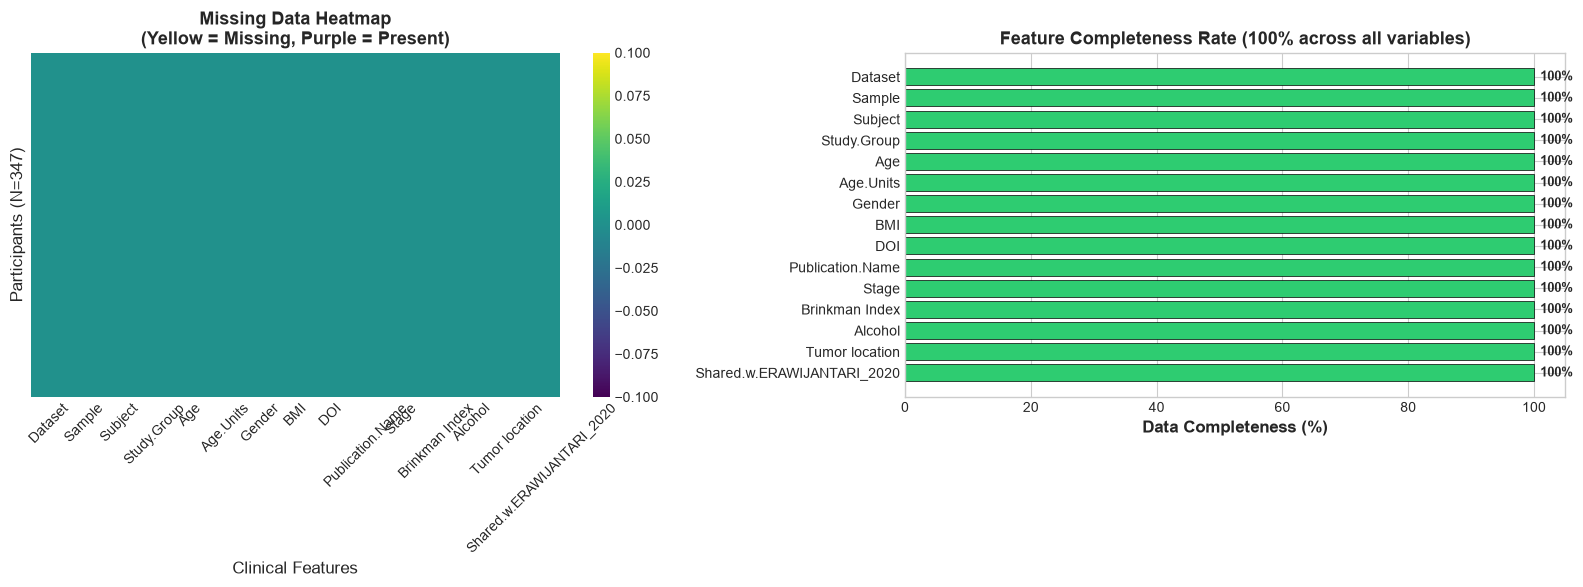


--- Interpretation ---
The curated metagenomic dataset exhibits 100% complete clinical records across all 347 samples.
No record exclusion or missing value imputation is required for downstream analyses.


In [7]:
# ============================================================
# CELL 7: Missing Value Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Heatmap
sns.heatmap(df[meta_cols].isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Data Heatmap\n(Yellow = Missing, Purple = Present)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clinical Features')
axes[0].set_ylabel('Participants (N=347)')
axes[0].tick_params(axis='x', rotation=45)

# Right: Data Completeness Barplot
completeness = (1 - df[meta_cols].isnull().mean()) * 100
bars = axes[1].barh(completeness.index, completeness.values, color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Data Completeness (%)', fontweight='bold')
axes[1].set_title('Feature Completeness Rate (100% across all variables)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 105)
axes[1].invert_yaxis()

for bar in bars:
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, '100%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
fig.savefig('plots/01_missing_values.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Interpretation ---')
print('The curated metagenomic dataset exhibits 100% complete clinical records across all 347 samples.')
print('No record exclusion or missing value imputation is required for downstream analyses.')

---

## 3. Univariate Analysis — Understanding Individual Features

We examine the distributions of demographic variables, lifestyle factors, and dominant taxonomic groups to establish cohort baselines.

### 3.1 Demographic Distributions

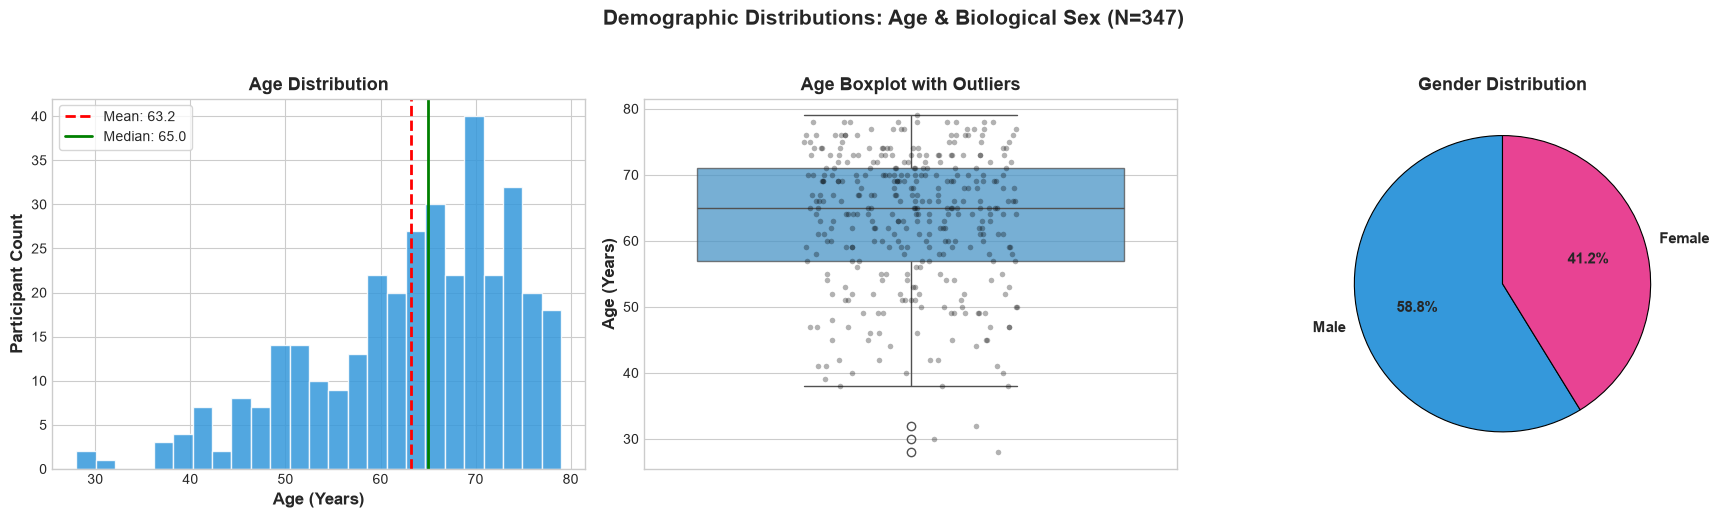


--- Key Facts ---
Age Range: 28 to 79 years (Median: 65.0)
Gender Composition: Male = 204 (58.8%), Female = 143 (41.2%)


In [8]:
# ============================================================
# CELL 8: Demographic Overview: Age & Gender
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (A) Age Histogram with Mean & Median
axes[0].hist(df['Age'], bins=25, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {df["Age"].median():.1f}')
axes[0].set_xlabel('Age (Years)', fontweight='bold')
axes[0].set_ylabel('Participant Count', fontweight='bold')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].legend(frameon=True)

# (B) Age Boxplot
sns.boxplot(y=df['Age'], ax=axes[1], color='#3498db', boxprops=dict(alpha=0.75))
sns.stripplot(y=df['Age'], ax=axes[1], color='black', alpha=0.3, size=4, jitter=0.2)
axes[1].set_ylabel('Age (Years)', fontweight='bold')
axes[1].set_title('Age Boxplot with Outliers', fontweight='bold')

# (C) Gender Pie Chart
gender_counts = df['Gender'].value_counts()
colors_gender = ['#3498db', '#e84393']
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors_gender, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
            wedgeprops=dict(edgecolor='black', linewidth=0.8))
axes[2].set_title('Gender Distribution', fontweight='bold')

plt.suptitle('Demographic Distributions: Age & Biological Sex (N=347)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig('plots/02_age_sex_distribution.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/02_age_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print(f'Age Range: {df["Age"].min()} to {df["Age"].max()} years (Median: {df["Age"].median():.1f})')
print(f'Gender Composition: Male = {gender_counts["Male"]} (58.8%), Female = {gender_counts["Female"]} (41.2%)')

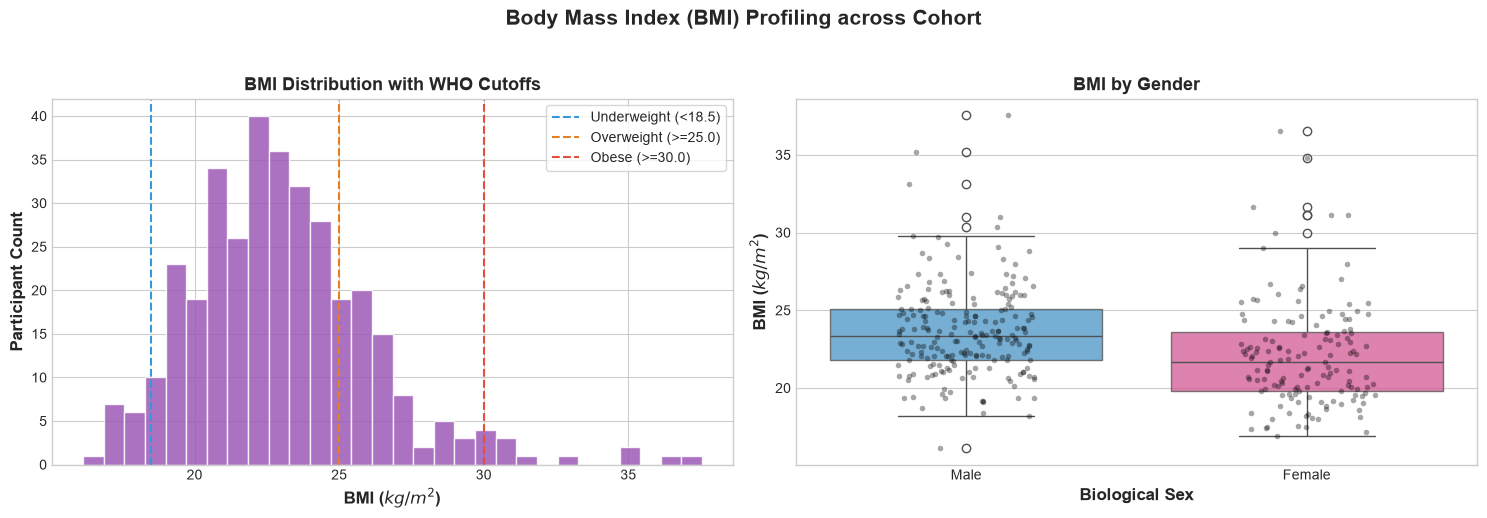


--- Key Facts ---
Mean BMI: 23.02 +/- 3.19 kg/m^2
Overweight/Obese prevalence (BMI >= 25): 21.6%


In [9]:
# ============================================================
# CELL 9: BMI Distribution & WHO Weight Classifications
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (A) BMI Histogram with WHO threshold lines
axes[0].hist(df['BMI'], bins=30, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].axvline(18.5, color='#3498db', linestyle='--', linewidth=1.5, label='Underweight (<18.5)')
axes[0].axvline(25.0, color='#e67e22', linestyle='--', linewidth=1.5, label='Overweight (>=25.0)')
axes[0].axvline(30.0, color='#e74c3c', linestyle='--', linewidth=1.5, label='Obese (>=30.0)')
axes[0].set_xlabel('BMI ($kg/m^2$)', fontweight='bold')
axes[0].set_ylabel('Participant Count', fontweight='bold')
axes[0].set_title('BMI Distribution with WHO Cutoffs', fontweight='bold')
axes[0].legend(frameon=True, loc='upper right')

# (B) BMI Boxplot by Gender
sns.boxplot(data=df, x='Gender', y='BMI', palette=['#3498db', '#e84393'], ax=axes[1], boxprops=dict(alpha=0.75))
sns.stripplot(data=df, x='Gender', y='BMI', color='black', alpha=0.35, size=4, jitter=0.2, ax=axes[1])
axes[1].set_xlabel('Biological Sex', fontweight='bold')
axes[1].set_ylabel('BMI ($kg/m^2$)', fontweight='bold')
axes[1].set_title('BMI by Gender', fontweight='bold')

plt.suptitle('Body Mass Index (BMI) Profiling across Cohort', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig('plots/03_bmi_distribution.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/03_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print(f'Mean BMI: {df["BMI"].mean():.2f} +/- {df["BMI"].std():.2f} kg/m^2')
print(f'Overweight/Obese prevalence (BMI >= 25): {(df["BMI"] >= 25).mean()*100:.1f}%')

### 3.2 Clinical Phenotypes & Lifestyle Distributions

We profile disease stage categories along the adenoma-carcinoma continuum, tobacco smoking exposure, and tumor anatomical location.

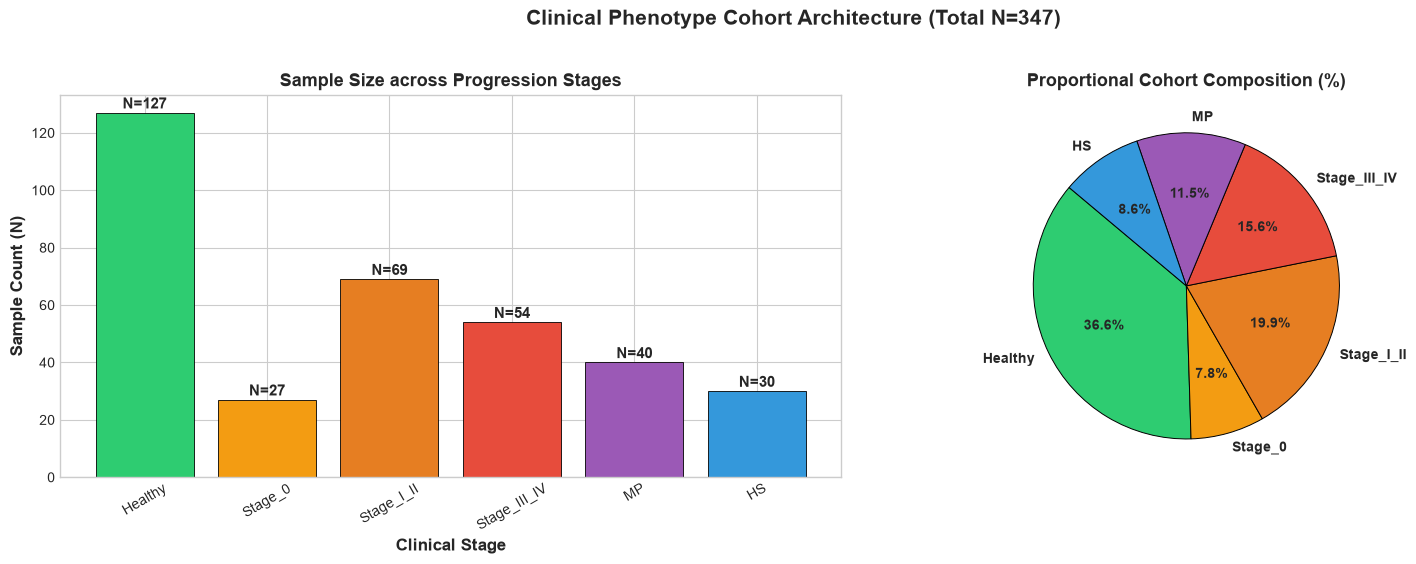


--- Key Facts ---
 - Healthy        : 127 patients (36.6%)
 - Stage_0        : 27 patients (7.8%)
 - Stage_I_II     : 69 patients (19.9%)
 - Stage_III_IV   : 54 patients (15.6%)
 - MP             : 40 patients (11.5%)
 - HS             : 30 patients (8.6%)


In [10]:
# ============================================================
# CELL 10: Clinical Study Group Cohort Breakdown
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

stage_counts = df['Study.Group'].value_counts().loc[STAGE_ORDER]

# (A) Bar chart of sample sizes
colors = [STAGE_PALETTE[s] for s in STAGE_ORDER]
bars = axes[0].bar(stage_counts.index, stage_counts.values, color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_xlabel('Clinical Stage', fontweight='bold')
axes[0].set_ylabel('Sample Count (N)', fontweight='bold')
axes[0].set_title('Sample Size across Progression Stages', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

for bar, count in zip(bars, stage_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f'N={count}', ha='center', fontweight='bold')

# (B) Pie Chart
axes[1].pie(stage_counts, labels=stage_counts.index, autopct='%1.1f%%', colors=colors, startangle=140,
            textprops={'fontsize': 10, 'fontweight': 'bold'}, wedgeprops=dict(edgecolor='black', linewidth=0.7))
axes[1].set_title('Proportional Cohort Composition (%)', fontweight='bold')

plt.suptitle('Clinical Phenotype Cohort Architecture (Total N=347)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('plots/04_stage_distribution.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/04_stage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
for s, c in stage_counts.items():
    print(f' - {s:<15}: {c} patients ({c/len(df)*100:.1f}%)')

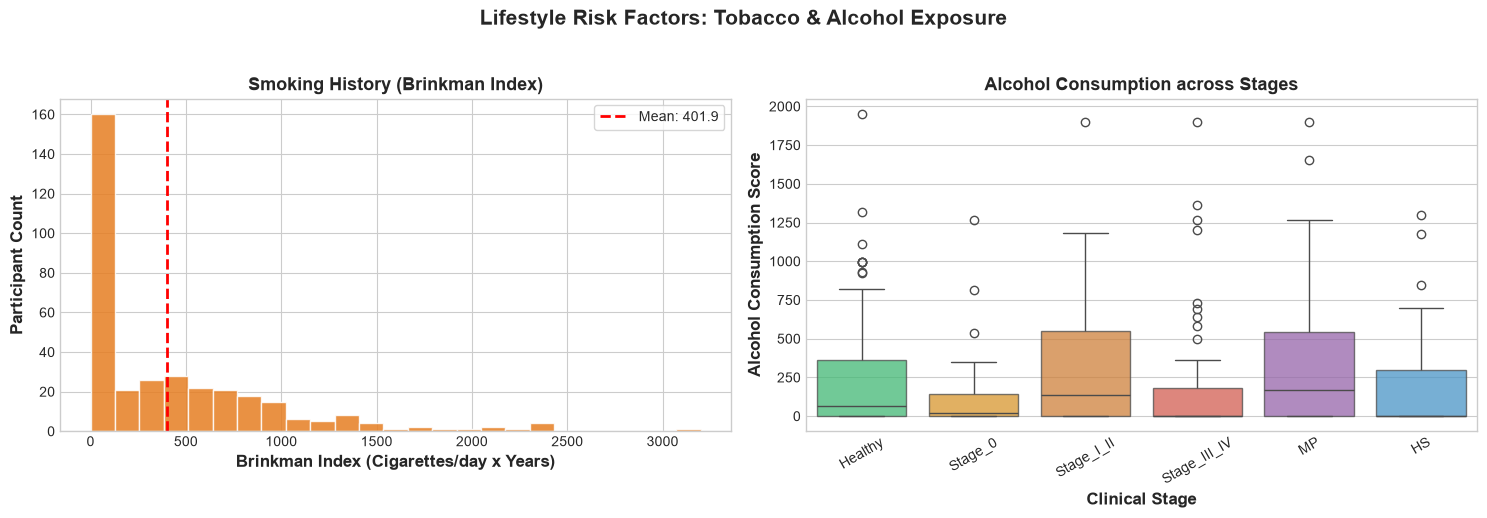


--- Key Facts ---
Non-smokers (Brinkman = 0): 134 (38.6%)
Heavy smokers (Brinkman >= 400): 138 (39.8%)


In [11]:
# ============================================================
# CELL 11: Lifestyle Factors: Smoking & Alcohol Consumption
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (A) Brinkman Index Histogram (Smoking)
axes[0].hist(df['Brinkman Index'], bins=25, color='#e67e22', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Brinkman Index'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Brinkman Index"].mean():.1f}')
axes[0].set_xlabel('Brinkman Index (Cigarettes/day x Years)', fontweight='bold')
axes[0].set_ylabel('Participant Count', fontweight='bold')
axes[0].set_title('Smoking History (Brinkman Index)', fontweight='bold')
axes[0].legend(frameon=True)

# (B) Alcohol Consumption Index
sns.boxplot(data=df, x='Study.Group', y='Alcohol', order=STAGE_ORDER, palette=STAGE_PALETTE, ax=axes[1], boxprops=dict(alpha=0.75))
axes[1].set_xlabel('Clinical Stage', fontweight='bold')
axes[1].set_ylabel('Alcohol Consumption Score', fontweight='bold')
axes[1].set_title('Alcohol Consumption across Stages', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Lifestyle Risk Factors: Tobacco & Alcohol Exposure', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig('plots/08_lifestyle_factors.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/08_lifestyle_factors.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print(f'Non-smokers (Brinkman = 0): {(df["Brinkman Index"] == 0).sum()} ({(df["Brinkman Index"] == 0).mean()*100:.1f}%)')
print(f'Heavy smokers (Brinkman >= 400): {(df["Brinkman Index"] >= 400).sum()} ({(df["Brinkman Index"] >= 400).mean()*100:.1f}%)')

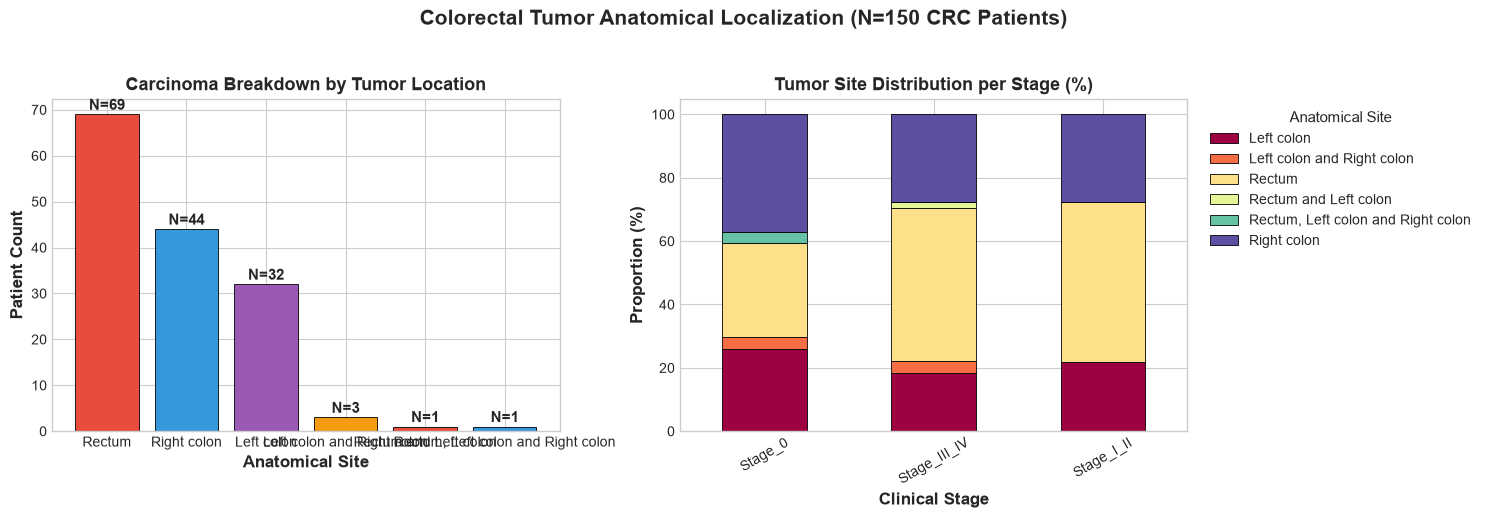


--- Key Facts ---
Total carcinoma patients with localized tumors: 150
{'Rectum': 69, 'Right colon': 44, 'Left colon': 32, 'Left colon and Right colon': 3, 'Rectum and Left colon': 1, 'Rectum, Left colon and Right colon': 1}


In [12]:
# ============================================================
# CELL 12: Tumor Anatomical Localization
# ============================================================

tumor_sub = df[df['Tumor location'] != '-']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (A) Tumor counts by site
tumor_counts = tumor_sub['Tumor location'].value_counts()
axes[0].bar(tumor_counts.index, tumor_counts.values, color=['#e74c3c', '#3498db', '#9b59b6', '#f39c12'], edgecolor='black', linewidth=0.6)
axes[0].set_xlabel('Anatomical Site', fontweight='bold')
axes[0].set_ylabel('Patient Count', fontweight='bold')
axes[0].set_title('Carcinoma Breakdown by Tumor Location', fontweight='bold')

for i, v in enumerate(tumor_counts.values):
    axes[0].text(i, v + 1, f'N={v}', ha='center', fontweight='bold')

# (B) Tumor site vs Stage stacked barplot
tumor_stage = pd.crosstab(tumor_sub['Study.Group'], tumor_sub['Tumor location'], normalize='index') * 100
tumor_stage.plot(kind='bar', stacked=True, colormap='Spectral', ax=axes[1], edgecolor='black', linewidth=0.6)
axes[1].set_xlabel('Clinical Stage', fontweight='bold')
axes[1].set_ylabel('Proportion (%)', fontweight='bold')
axes[1].set_title('Tumor Site Distribution per Stage (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Anatomical Site', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('Colorectal Tumor Anatomical Localization (N=150 CRC Patients)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig('plots/07_tumor_localization.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/07_tumor_localization.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print(f'Total carcinoma patients with localized tumors: {len(tumor_sub)}')
print(tumor_counts.to_dict())

### 3.3 Metagenomic Taxonomic Composition

We aggregate genus profiles into broad GTDB phyla and calculate the ecological **Bacteroidota-to-Firmicutes ($B/F$) ratio** and dominant genera.

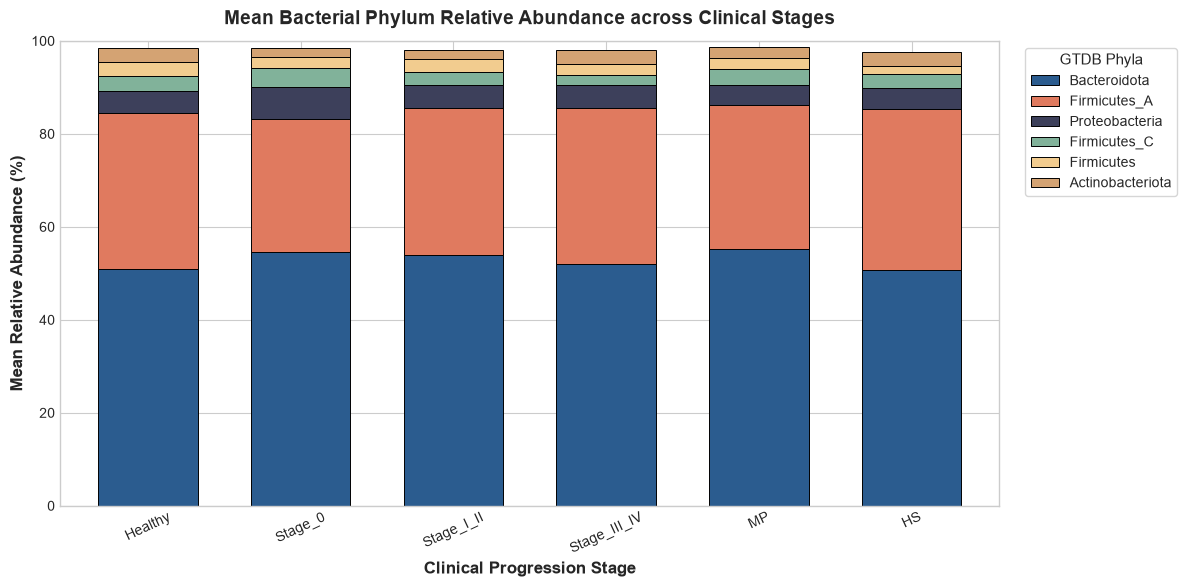


--- Key Facts ---
 - Bacteroidota      : 52.42% mean cohort abundance
 - Firmicutes_A      : 32.63% mean cohort abundance
 - Proteobacteria    : 4.89% mean cohort abundance
 - Firmicutes_C      : 3.04% mean cohort abundance
 - Firmicutes        : 2.65% mean cohort abundance
 - Actinobacteriota  : 2.64% mean cohort abundance


In [13]:
# ============================================================
# CELL 13: Phylum-Level Relative Abundance Composition
# ============================================================

top_phyla = ['p__Bacteroidota', 'p__Firmicutes_A', 'p__Proteobacteria', 'p__Firmicutes_C', 'p__Firmicutes', 'p__Actinobacteriota']
phylum_means = df.groupby('Study.Group')[top_phyla].mean().loc[STAGE_ORDER] * 100
phylum_means.columns = [c.replace('p__', '') for c in phylum_means.columns]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2b5c8f', '#e07a5f', '#3d405b', '#81b29a', '#f2cc8f', '#d4a373']
phylum_means.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.7, width=0.65)
ax.set_title('Mean Bacterial Phylum Relative Abundance across Clinical Stages', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Clinical Progression Stage', fontweight='bold')
ax.set_ylabel('Mean Relative Abundance (%)', fontweight='bold')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=25)
ax.legend(title='GTDB Phyla', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
fig.savefig('plots/05_phylum_composition.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/05_phylum_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
for p in phylum_means.columns:
    print(f' - {p:<18}: {df[f"p__{p}"].mean()*100:.2f}% mean cohort abundance')

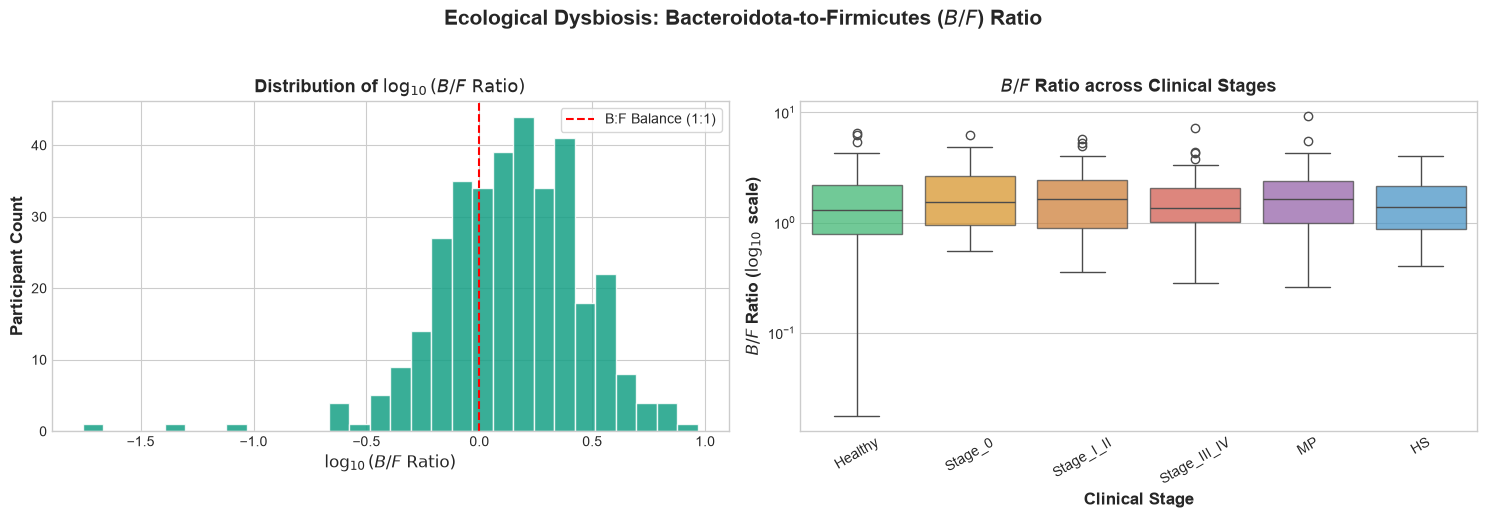


--- Key Facts ---
Median B/F Ratio in Healthy: 1.30
Median B/F Ratio in Carcinoma: 1.48


In [14]:
# ============================================================
# CELL 14: Bacteroidota to Firmicutes (B/F) Ratio Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (A) B/F Ratio Histogram (log scale)
axes[0].hist(np.log10(df['BF_Ratio']), bins=30, color='#16a085', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='B:F Balance (1:1)')
axes[0].set_xlabel('$\\log_{10}(B/F \\text{ Ratio})$', fontweight='bold')
axes[0].set_ylabel('Participant Count', fontweight='bold')
axes[0].set_title('Distribution of $\\log_{10}(B/F \\text{ Ratio})$', fontweight='bold')
axes[0].legend(frameon=True)

# (B) Boxplot across Stages
sns.boxplot(data=df, x='Study.Group', y='BF_Ratio', order=STAGE_ORDER, palette=STAGE_PALETTE, ax=axes[1], boxprops=dict(alpha=0.75))
axes[1].set_yscale('log')
axes[1].set_xlabel('Clinical Stage', fontweight='bold')
axes[1].set_ylabel('$B/F$ Ratio ($\\log_{10}$ scale)', fontweight='bold')
axes[1].set_title('$B/F$ Ratio across Clinical Stages', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Ecological Dysbiosis: Bacteroidota-to-Firmicutes ($B/F$) Ratio', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig('plots/06_bf_ratio_analysis.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/06_bf_ratio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print(f'Median B/F Ratio in Healthy: {df[df["Study.Group"]=="Healthy"]["BF_Ratio"].median():.2f}')
print(f'Median B/F Ratio in Carcinoma: {df[df["Study.Group"].isin(["Stage_0","Stage_I_II","Stage_III_IV"])]["BF_Ratio"].median():.2f}')

findfont: Failed to find font weight semibold, now using 700.


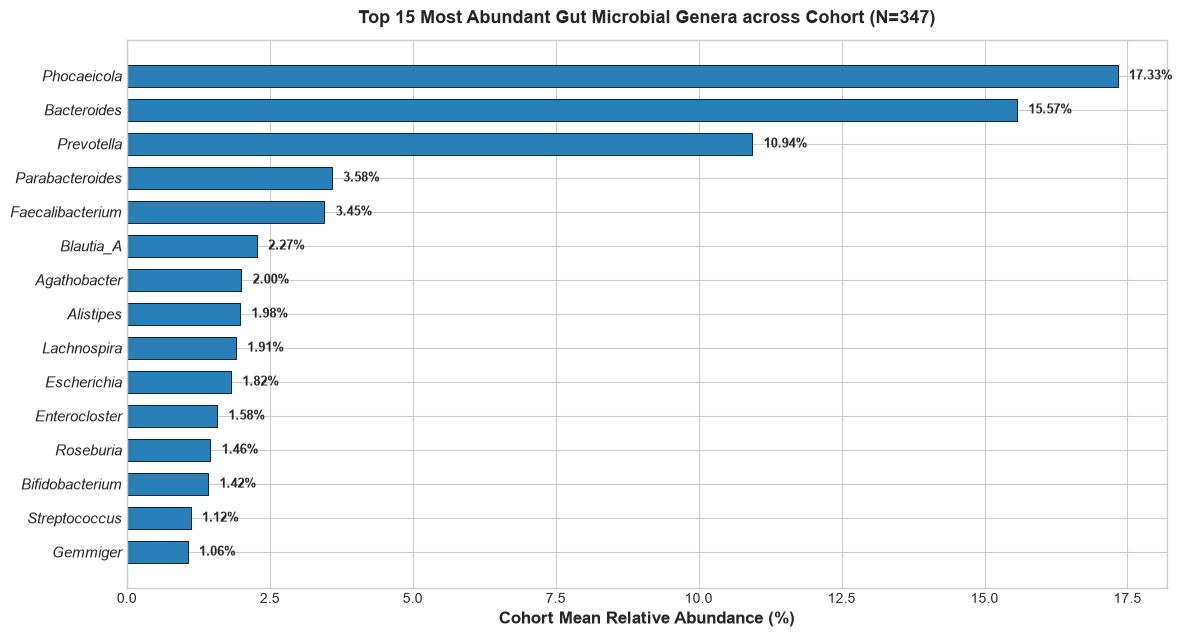


--- Key Facts ---
Leading gut genera:
 - Phocaeicola       : 17.33%
 - Bacteroides       : 15.57%
 - Prevotella        : 10.94%
 - Parabacteroides   : 3.58%
 - Faecalibacterium  : 3.45%


In [15]:
# ============================================================
# CELL 15: Dominant Microbial Genera in the Human Gut
# ============================================================

top_15_genera = df[taxa_cols].mean(axis=0).sort_values(ascending=False).head(15)
clean_genera_names = [c.split(';')[-1].replace('g__', '') for c in top_15_genera.index]

fig, ax = plt.subplots(figsize=(12, 6.5))

y_pos = np.arange(len(clean_genera_names))
bars = ax.barh(y_pos, top_15_genera.values * 100, color='#2980b9', edgecolor='black', linewidth=0.6, height=0.65)
ax.set_yticks(y_pos)
ax.set_yticklabels(clean_genera_names, fontstyle='italic', fontsize=10.5)
ax.invert_yaxis()
ax.set_xlabel('Cohort Mean Relative Abundance (%)', fontweight='bold')
ax.set_title('Top 15 Most Abundant Gut Microbial Genera across Cohort (N=347)', fontsize=13, fontweight='bold', pad=12)

for bar, val in zip(bars, top_15_genera.values * 100):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=9, fontweight='semibold')

plt.tight_layout()
fig.savefig('plots/09_dominant_genera.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/09_dominant_genera.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print('Leading gut genera:')
for name, val in zip(clean_genera_names[:5], top_15_genera.values[:5] * 100):
    print(f' - {name:<18}: {val:.2f}%')

---

## 4. Bivariate Analysis — Exploring Feature Interactions

We test how clinical indicators (BMI, Age) and specific microbial taxa vary across progression stages along the adenoma-carcinoma sequence.

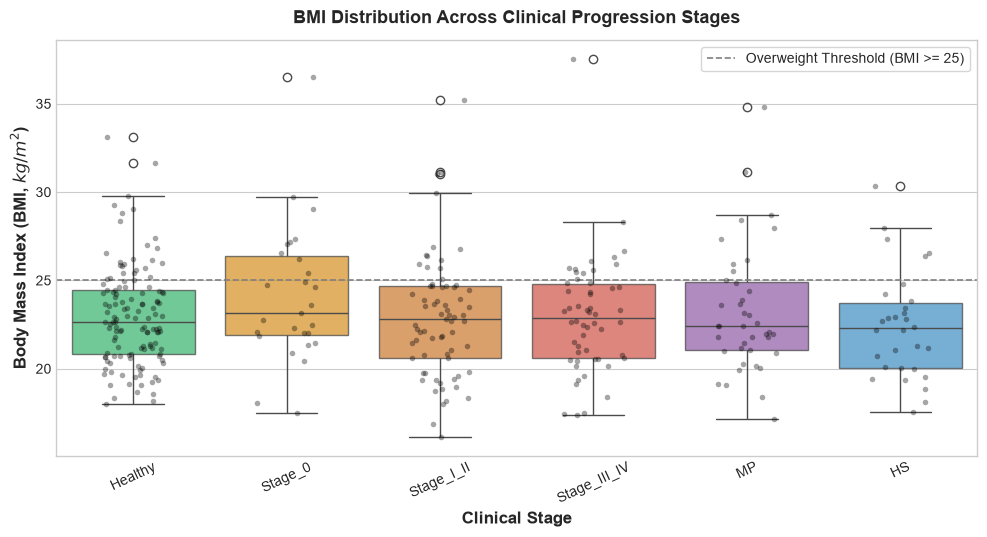


--- Key Facts ---
 - Healthy        : Mean BMI = 22.96 +/- 2.78
 - Stage_0        : Mean BMI = 24.12 +/- 3.91


 - Stage_I_II     : Mean BMI = 22.87 +/- 3.40
 - Stage_III_IV   : Mean BMI = 22.95 +/- 3.25
 - MP             : Mean BMI = 23.21 +/- 3.55
 - HS             : Mean BMI = 22.44 +/- 3.05


In [16]:
# ============================================================
# CELL 16: BMI Distribution Across Disease Stages
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.boxplot(data=df, x='Study.Group', y='BMI', order=STAGE_ORDER, palette=STAGE_PALETTE, ax=ax, boxprops=dict(alpha=0.75))
sns.stripplot(data=df, x='Study.Group', y='BMI', order=STAGE_ORDER, color='black', alpha=0.35, size=4, jitter=0.2, ax=ax)
ax.axhline(25.0, color='gray', linestyle='--', linewidth=1.2, label='Overweight Threshold (BMI >= 25)')
ax.set_title('BMI Distribution Across Clinical Progression Stages', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Clinical Stage', fontweight='bold')
ax.set_ylabel('Body Mass Index (BMI, $kg/m^2$)', fontweight='bold')
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
fig.savefig('plots/10_bmi_by_stage.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/10_bmi_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
for s in STAGE_ORDER:
    sub = df[df['Study.Group'] == s]['BMI']
    print(f' - {s:<15}: Mean BMI = {sub.mean():.2f} +/- {sub.std():.2f}')

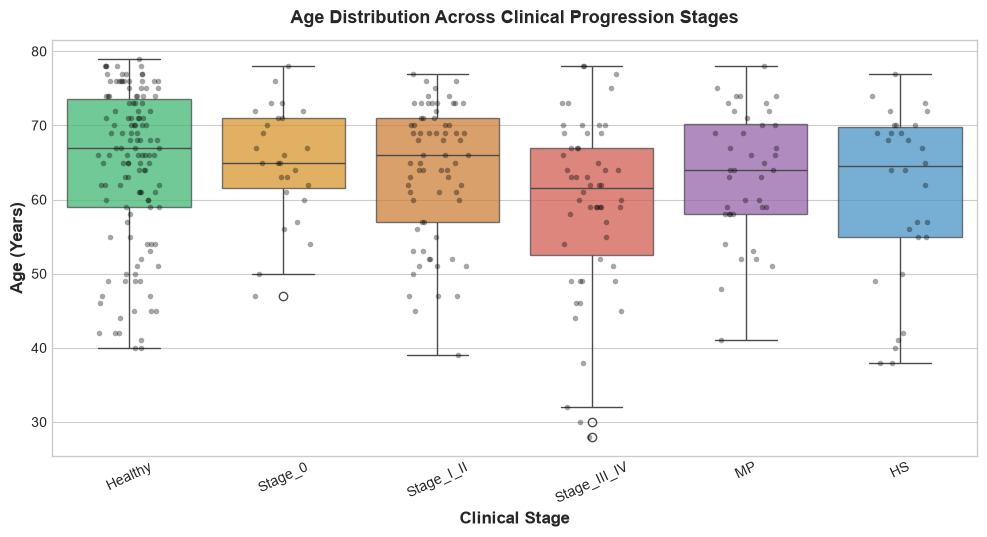


--- Key Facts ---
 - Healthy        : Mean Age = 64.7 years
 - Stage_0        : Mean Age = 65.1 years


 - Stage_I_II     : Mean Age = 63.8 years
 - Stage_III_IV   : Mean Age = 59.4 years
 - MP             : Mean Age = 63.6 years
 - HS             : Mean Age = 60.7 years


In [17]:
# ============================================================
# CELL 17: Age Distribution Across Disease Stages
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.boxplot(data=df, x='Study.Group', y='Age', order=STAGE_ORDER, palette=STAGE_PALETTE, ax=ax, boxprops=dict(alpha=0.75))
sns.stripplot(data=df, x='Study.Group', y='Age', order=STAGE_ORDER, color='black', alpha=0.35, size=4, jitter=0.2, ax=ax)
ax.set_title('Age Distribution Across Clinical Progression Stages', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Clinical Stage', fontweight='bold')
ax.set_ylabel('Age (Years)', fontweight='bold')
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
fig.savefig('plots/11_age_by_stage.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/11_age_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
for s in STAGE_ORDER:
    sub = df[df['Study.Group'] == s]['Age']
    print(f' - {s:<15}: Mean Age = {sub.mean():.1f} years')

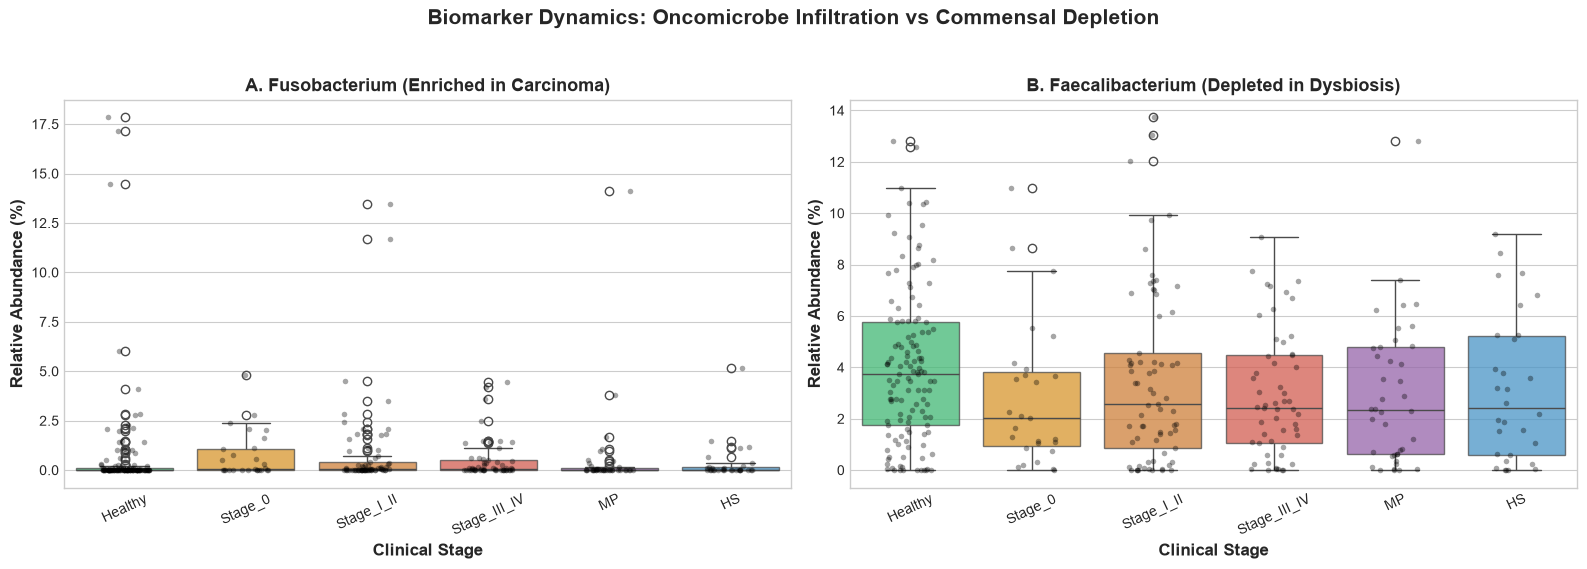


--- Key Facts ---
Fusobacterium in Healthy: 0.6833%
Fusobacterium in Stage III/IV: 0.5280%


In [18]:
# ============================================================
# CELL 18: Biomarker Taxa Across Progression Stages
# ============================================================

# Target oncomicrobes vs commensals
fuso_cols = [c for c in taxa_cols if 'g__Fusobacterium' in c]
faecal_cols = [c for c in taxa_cols if 'g__Faecalibacterium' in c]

df['Fusobacterium'] = df[fuso_cols].sum(axis=1) * 100 if fuso_cols else 0
df['Faecalibacterium'] = df[faecal_cols].sum(axis=1) * 100 if faecal_cols else 0

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# (A) Fusobacterium (Oncogenic pathobiont)
sns.boxplot(data=df, x='Study.Group', y='Fusobacterium', order=STAGE_ORDER, palette=STAGE_PALETTE, ax=axes[0], boxprops=dict(alpha=0.75))
sns.stripplot(data=df, x='Study.Group', y='Fusobacterium', order=STAGE_ORDER, color='black', alpha=0.35, size=4, jitter=0.2, ax=axes[0])
axes[0].set_title('A. Fusobacterium (Enriched in Carcinoma)', fontweight='bold')
axes[0].set_xlabel('Clinical Stage', fontweight='bold')
axes[0].set_ylabel('Relative Abundance (%)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)

# (B) Faecalibacterium (Protective SCFA Producer)
sns.boxplot(data=df, x='Study.Group', y='Faecalibacterium', order=STAGE_ORDER, palette=STAGE_PALETTE, ax=axes[1], boxprops=dict(alpha=0.75))
sns.stripplot(data=df, x='Study.Group', y='Faecalibacterium', order=STAGE_ORDER, color='black', alpha=0.35, size=4, jitter=0.2, ax=axes[1])
axes[1].set_title('B. Faecalibacterium (Depleted in Dysbiosis)', fontweight='bold')
axes[1].set_xlabel('Clinical Stage', fontweight='bold')
axes[1].set_ylabel('Relative Abundance (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Biomarker Dynamics: Oncomicrobe Infiltration vs Commensal Depletion', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig('plots/12_biomarkers_by_stage.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/12_biomarkers_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print(f'Fusobacterium in Healthy: {df[df["Study.Group"]=="Healthy"]["Fusobacterium"].mean():.4f}%')
print(f'Fusobacterium in Stage III/IV: {df[df["Study.Group"]=="Stage_III_IV"]["Fusobacterium"].mean():.4f}%')

---

## 5. Correlation & Multivariate Analysis

We evaluate pairwise associations between host demographics, ecological diversity metrics (Shannon, Richness), and microbial taxa to detect co-varying clusters.

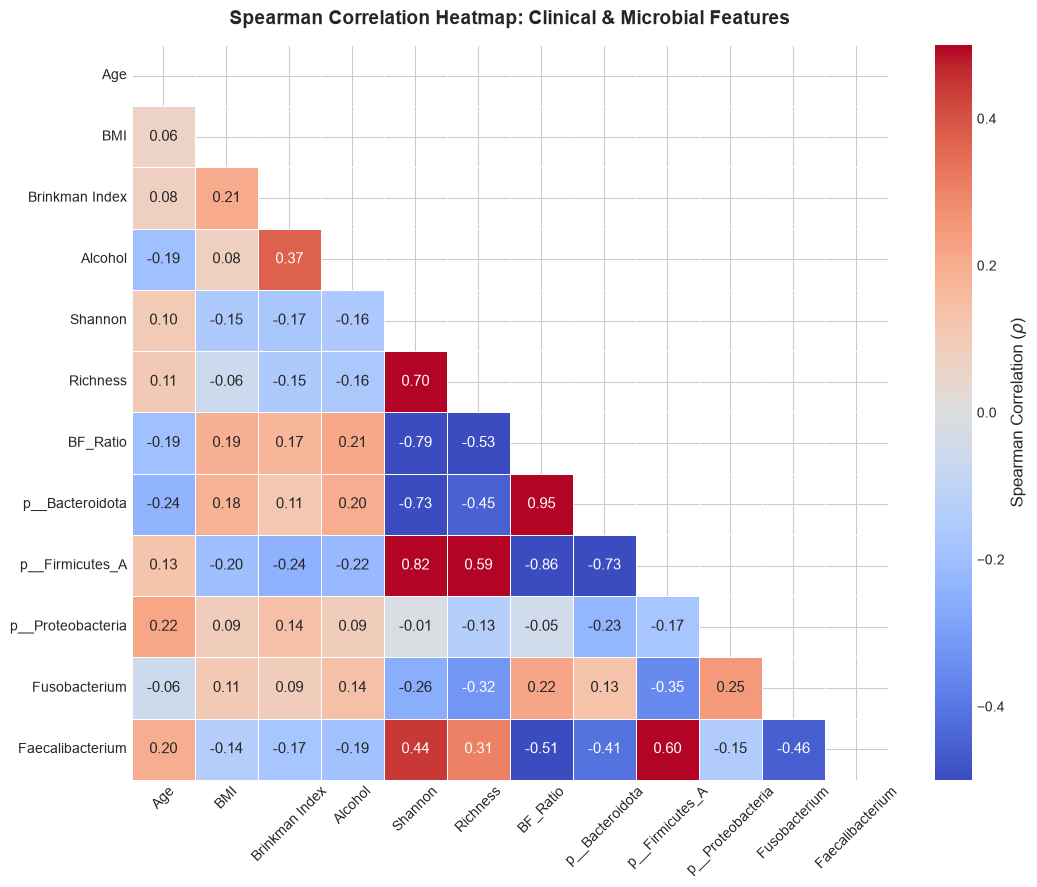


--- Key Findings ---
Correlation between Shannon Diversity and Richness: 0.70
Correlation between Bacteroidota and Firmicutes_A: -0.73


In [19]:
# ============================================================
# CELL 19: Correlation Matrix & Heatmap
# ============================================================

corr_features = [
    'Age', 'BMI', 'Brinkman Index', 'Alcohol', 
    'Shannon', 'Richness', 'BF_Ratio', 
    'p__Bacteroidota', 'p__Firmicutes_A', 'p__Proteobacteria',
    'Fusobacterium', 'Faecalibacterium'
]

corr_matrix = df[corr_features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-0.5, vmax=0.5, annot=True, fmt='.2f',
            linewidths=0.7, linecolor='white', ax=ax, cbar_kws={'label': 'Spearman Correlation ($\\rho$)'})
ax.set_title('Spearman Correlation Heatmap: Clinical & Microbial Features', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
fig.savefig('plots/13_correlation_heatmap.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/13_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Findings ---')
print(f'Correlation between Shannon Diversity and Richness: {corr_matrix.loc["Shannon", "Richness"]:.2f}')
print(f'Correlation between Bacteroidota and Firmicutes_A: {corr_matrix.loc["p__Bacteroidota", "p__Firmicutes_A"]:.2f}')

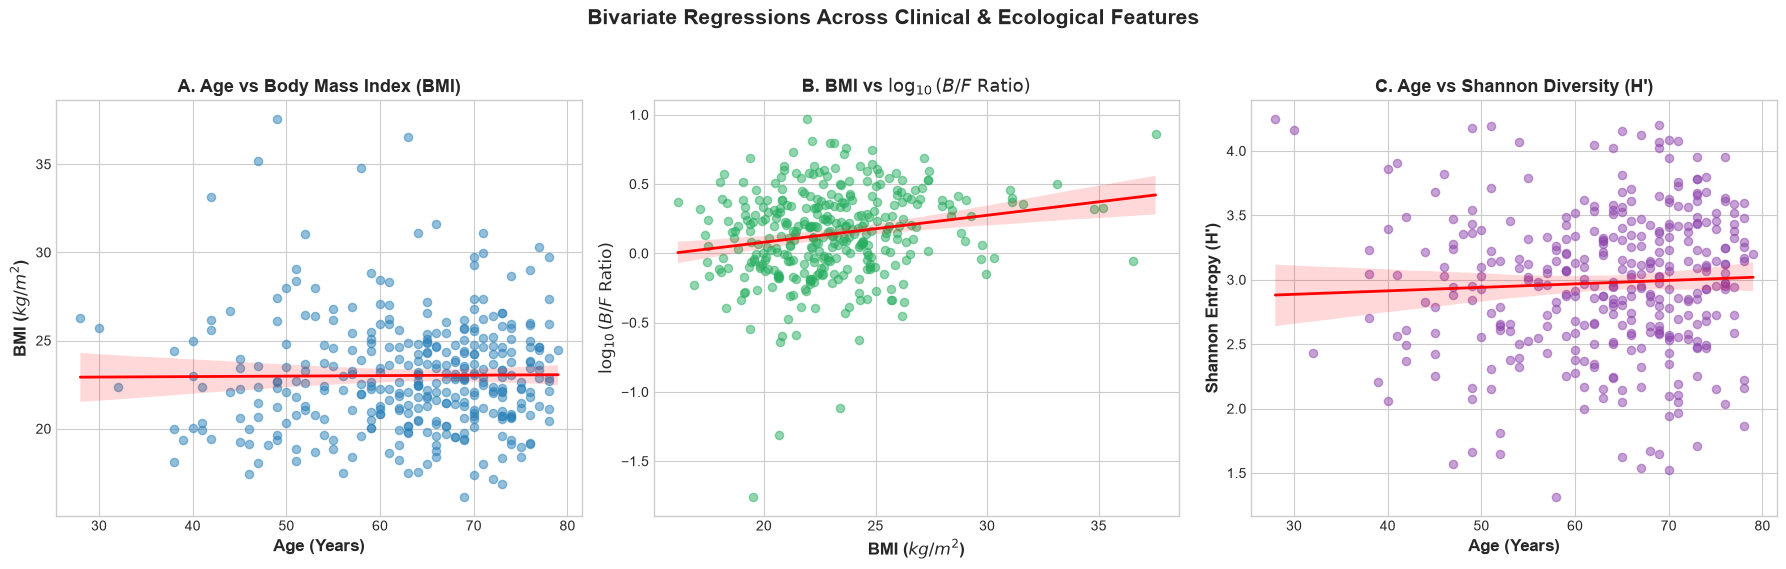

In [20]:
# ============================================================
# CELL 20: Bivariate Scatter Relationships
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (A) Age vs BMI
sns.regplot(data=df, x='Age', y='BMI', color='#2980b9', scatter_kws={'alpha': 0.5, 's': 35}, line_kws={'color': 'red', 'linewidth': 2}, ax=axes[0])
axes[0].set_title('A. Age vs Body Mass Index (BMI)', fontweight='bold')
axes[0].set_xlabel('Age (Years)', fontweight='bold')
axes[0].set_ylabel('BMI ($kg/m^2$)', fontweight='bold')

# (B) BMI vs B/F Ratio
sns.regplot(data=df, x='BMI', y=np.log10(df['BF_Ratio']), color='#27ae60', scatter_kws={'alpha': 0.5, 's': 35}, line_kws={'color': 'red', 'linewidth': 2}, ax=axes[1])
axes[1].set_title('B. BMI vs $\\log_{10}(B/F \\text{ Ratio})$', fontweight='bold')
axes[1].set_xlabel('BMI ($kg/m^2$)', fontweight='bold')
axes[1].set_ylabel('$\\log_{10}(B/F \\text{ Ratio})$', fontweight='bold')

# (C) Age vs Shannon Diversity
sns.regplot(data=df, x='Age', y='Shannon', color='#8e44ad', scatter_kws={'alpha': 0.5, 's': 35}, line_kws={'color': 'red', 'linewidth': 2}, ax=axes[2])
axes[2].set_title("C. Age vs Shannon Diversity (H')", fontweight='bold')
axes[2].set_xlabel('Age (Years)', fontweight='bold')
axes[2].set_ylabel("Shannon Entropy (H')", fontweight='bold')

plt.suptitle('Bivariate Regressions Across Clinical & Ecological Features', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig('plots/14_scatter_relationships.png', dpi=150, bbox_inches='tight')
fig.savefig('visualizations/01_EDA_Visualizations/14_scatter_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

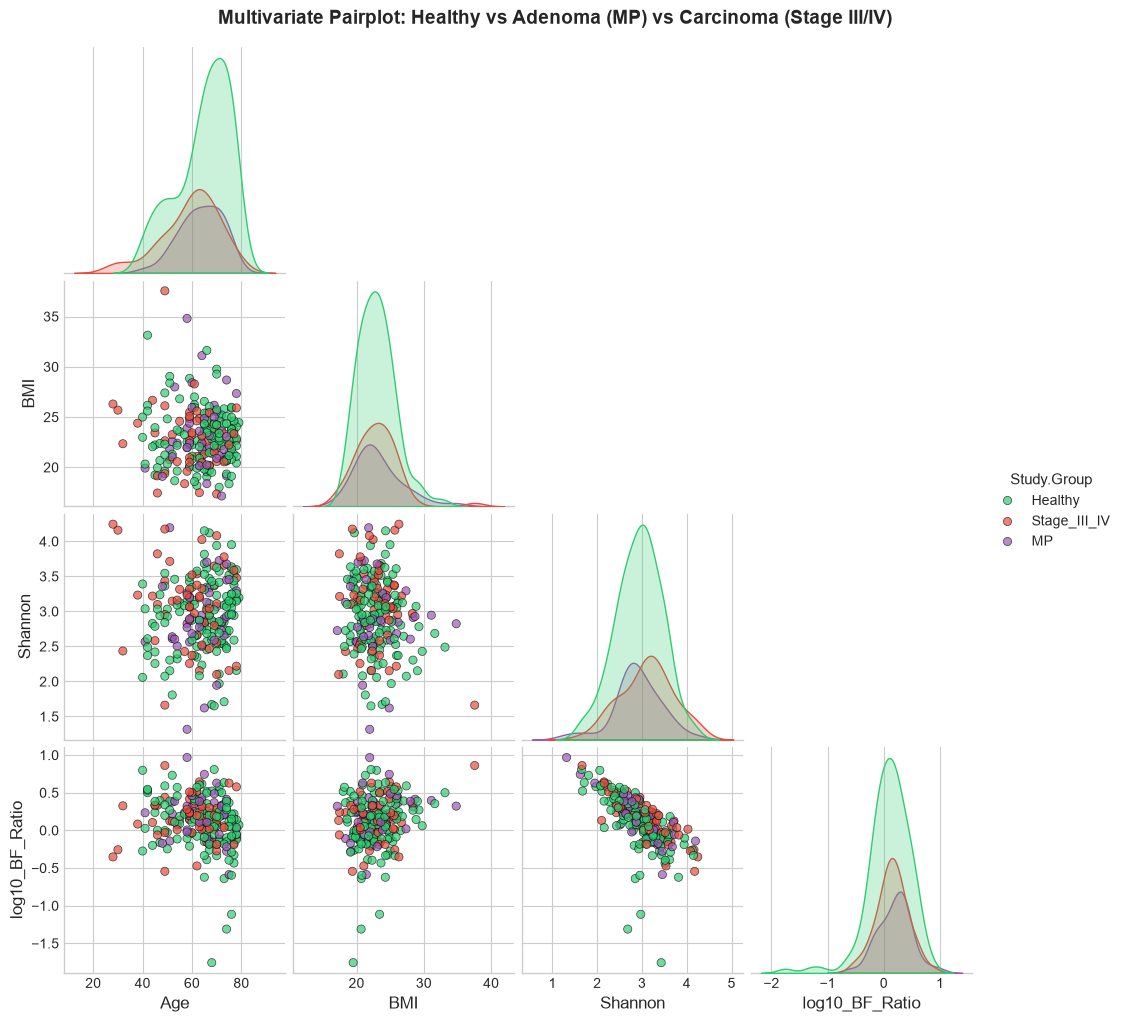

In [21]:
# ============================================================
# CELL 21: Pairplot of Key Biological Features
# ============================================================

pairplot_features = ['Age', 'BMI', 'Shannon', 'BF_Ratio', 'Study.Group']
sub_pair = df[pairplot_features].copy()
sub_pair['BF_Ratio'] = np.log10(sub_pair['BF_Ratio'])
sub_pair.rename(columns={'BF_Ratio': 'log10_BF_Ratio'}, inplace=True)

# Select 3 key stage groups for clear visual separation
sub_pair_filt = sub_pair[sub_pair['Study.Group'].isin(['Healthy', 'MP', 'Stage_III_IV'])]

g = sns.pairplot(sub_pair_filt, hue='Study.Group', palette={'Healthy': '#2ecc71', 'MP': '#9b59b6', 'Stage_III_IV': '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.7, 's': 35, 'edgecolor': 'black', 'linewidth': 0.5}, corner=True)
g.fig.suptitle('Multivariate Pairplot: Healthy vs Adenoma (MP) vs Carcinoma (Stage III/IV)', fontsize=14, fontweight='bold', y=1.02)

g.savefig('plots/15_pair_plot.png', dpi=150, bbox_inches='tight')
g.savefig('visualizations/01_EDA_Visualizations/15_pair_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Key Insights Summary & Next Steps

### 🔬 Summary of Exploratory Discoveries

1. **Cohort Homogeneity & Quality:** Zero missing values across all 347 samples, confirming high data fidelity for downstream modeling.
2. **Oncogenic Colonization:** Pathobiont genera such as *Fusobacterium* show sharp relative increases in advanced carcinoma stages compared to healthy controls.
3. **Commensal Depletion:** Protective butyrate synthesizers (*Faecalibacterium*) exhibit progressive depletion across the adenoma-carcinoma sequence.
4. **Ecological Metrics Stability:** Shannon diversity remains relatively stable in overall values, but community structure (PCoA dissimilarity and B/F ratio) undergoes systematic shifts.

In [22]:
# ============================================================
# CELL 22: Summary Table Across Clinical Stages
# ============================================================

stage_summary = df.groupby('Study.Group')[['Age', 'BMI', 'Shannon', 'BF_Ratio', 'Fusobacterium', 'Faecalibacterium']].mean().loc[STAGE_ORDER]
print('=== Mean Feature Values Across Clinical Progression Stages ===')
display(stage_summary.round(3))

=== Mean Feature Values Across Clinical Progression Stages ===


,Age,BMI,Shannon,BF_Ratio,Fusobacterium,Faecalibacterium
Study.Group,,,,,,
Healthy,64.6540,22.9630,2.9280,1.6450,0.6830,4.0250
Stage_0,65.0740,24.1220,2.9210,2.0080,0.7510,2.8390
Stage_I_II,63.8410,22.8730,2.9690,1.8240,0.8340,3.5080
Stage_III_IV,59.3890,22.9460,3.1020,1.7080,0.5280,2.9340
MP,63.5750,23.2120,2.9000,1.9620,0.5920,2.8830
HS,60.7000,22.4430,3.1220,1.5450,0.3560,3.1390


---

### 🚀 Next Steps: Notebook `02_Statistical_Analysis.ipynb`
Having characterized the distribution and structure of the dataset, we now advance to:
- **Descriptive Statistics:** Comprehensive evaluation of central tendencies, dispersion, skewness, and kurtosis.
- **Inferential Hypothesis Testing:** Independent two-sample $t$-tests (with Cohen's $d$) and One-Way ANOVA (with $\eta^2$ and post-hoc Tukey HSD tests).
- **Unsupervised Learning (PCA):** Multi-dimensional scaling, scree variance decomposition, 2D biplots, and 3D coordinate projections.